# Formative 2, Task 3: Audio Data Processing and Voiceprint Verification

**Author:** Divine. This notebook builds the audio pipeline: load the team voice clips, explore them, augment them, extract features, and train a voiceprint verification model.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import librosa.display
import joblib
import matplotlib.pyplot as plt
from IPython.display import Audio
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
TEAM_MEMBERS = ["David", "Bakhit", "Divine", "Serein"]
AUDIO_DIR = "../audio"
SR = 22050

member_files = {}
for name in TEAM_MEMBERS:
    files = sorted(glob.glob(f"{AUDIO_DIR}/{name}*.wav"))
    member_files[name] = files
    print(f"{name}: {len(files)} files found")

stranger_files = sorted(glob.glob(f"{AUDIO_DIR}/stranger*.wav"))
print(f"stranger: {len(stranger_files)} files found")

David: 2 files found
Bakhit: 2 files found
Divine: 2 files found
Serein: 2 files found
stranger: 2 files found


## 1. Load and Display Audio Samples

In [3]:
audio_data = {}
for name in TEAM_MEMBERS:
    for path in member_files[name]:
        y, sr = librosa.load(path, sr=SR)
        audio_data[path] = (y, sr)
        duration = len(y) / sr
        print(f"{os.path.basename(path)}: duration={duration:.2f}s, sr={sr}")

David1.wav: duration=2.05s, sr=22050
David2.wav: duration=1.33s, sr=22050
Bakhit1.wav: duration=2.45s, sr=22050
Bakhit2.wav: duration=1.95s, sr=22050
Divine1.wav: duration=2.37s, sr=22050
Divine2.wav: duration=2.07s, sr=22050
Serein1.wav: duration=2.57s, sr=22050
Serein2.wav: duration=2.37s, sr=22050


/var/folders/7h/f1hhjprx7n7f5vnswz78l0kh0000gn/T/ipykernel_6073/1726052612.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SR)
/private/tmp/claude-501/-Users-macbook-Desktop-Project-Multimodal-Data-Preprocessing/abd8ede9-db1d-4b10-8729-40bd11871dd1/scratchpad/venv312/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


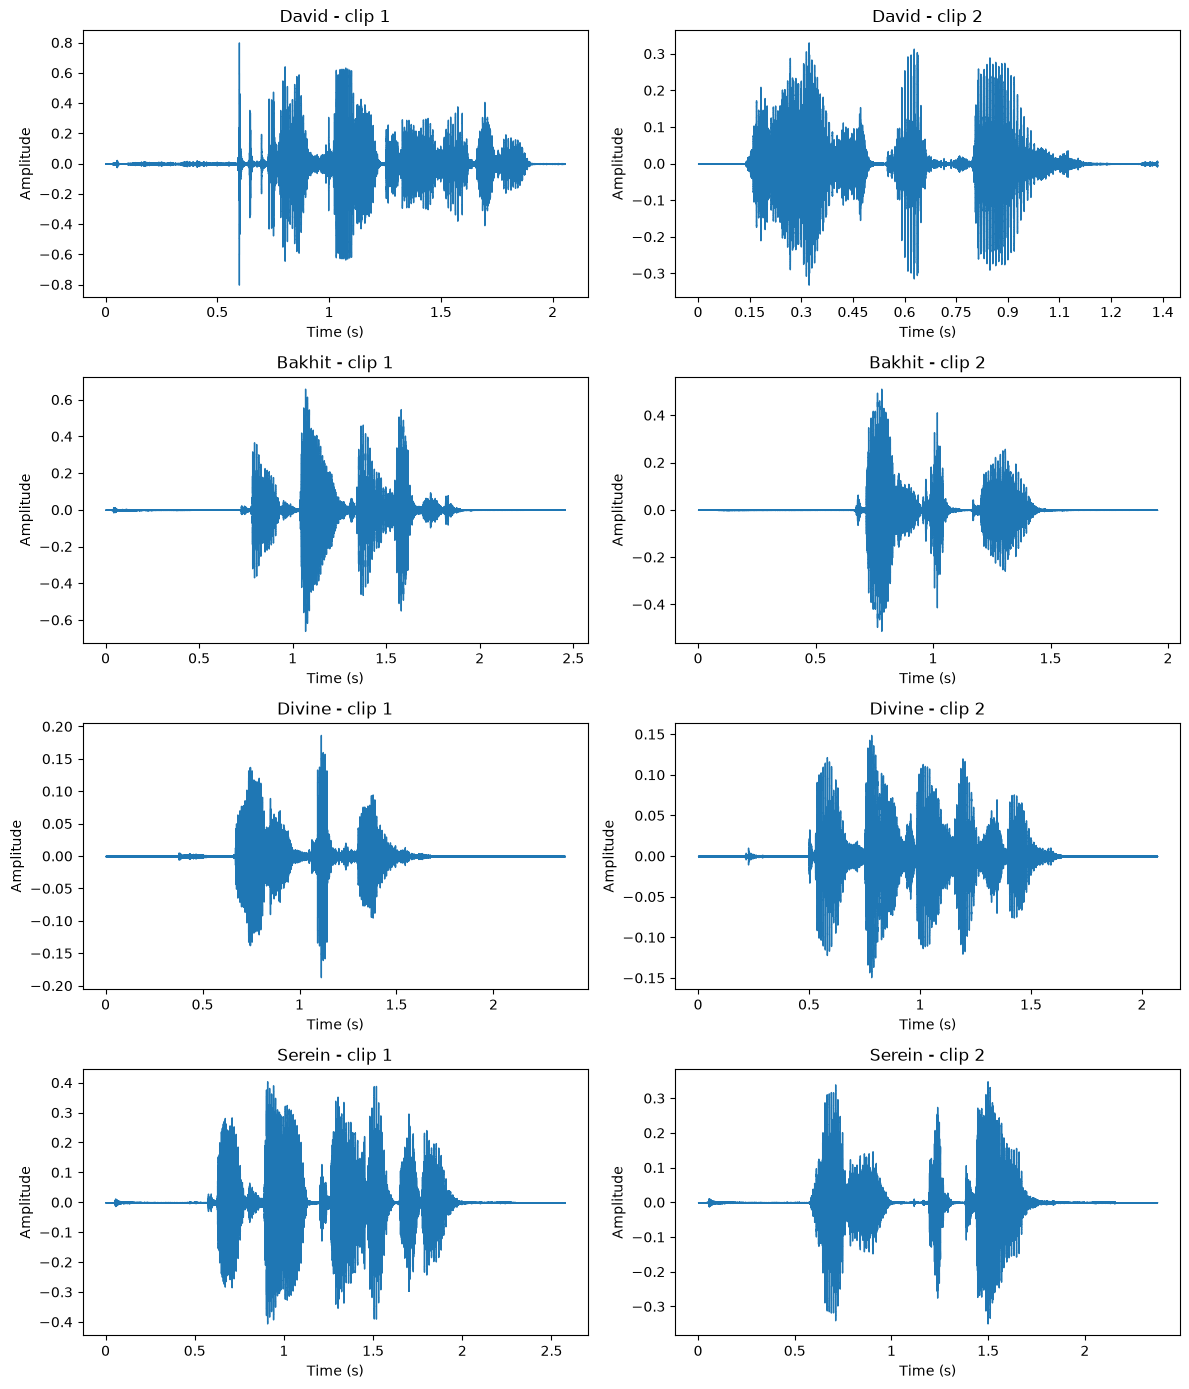

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
for row, name in enumerate(TEAM_MEMBERS):
    for col, path in enumerate(member_files[name]):
        y, sr = audio_data[path]
        ax = axes[row, col]
        librosa.display.waveshow(y, sr=sr, ax=ax)
        ax.set_title(f"{name} - clip {col + 1}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
fig.tight_layout()
fig.savefig("../plots/audio_waveforms.png", dpi=120)
plt.show()

Divine's two clips sit far quieter than everyone else's: peak amplitude tops out around 0.2, versus 0.4 to 0.8 for the other three members. This lines up with the RMS energy feature extracted later, where Divine averages 0.009 against 0.027 to 0.045 for the rest, so this is a real, measurable gap, not just a visual impression. David's clip 1 has one sharp spike near t=0.6s reaching 0.8, well above the rest of that clip's syllable peaks (0.3 to 0.6), which looks like a plosive or mic pop rather than normal speech. Clip duration ranges from 1.33s (David2) to 2.57s (Serein1), a spread of over a second even though every clip is the same short phrase, so the time-stretch augmentation has real variation to work with.

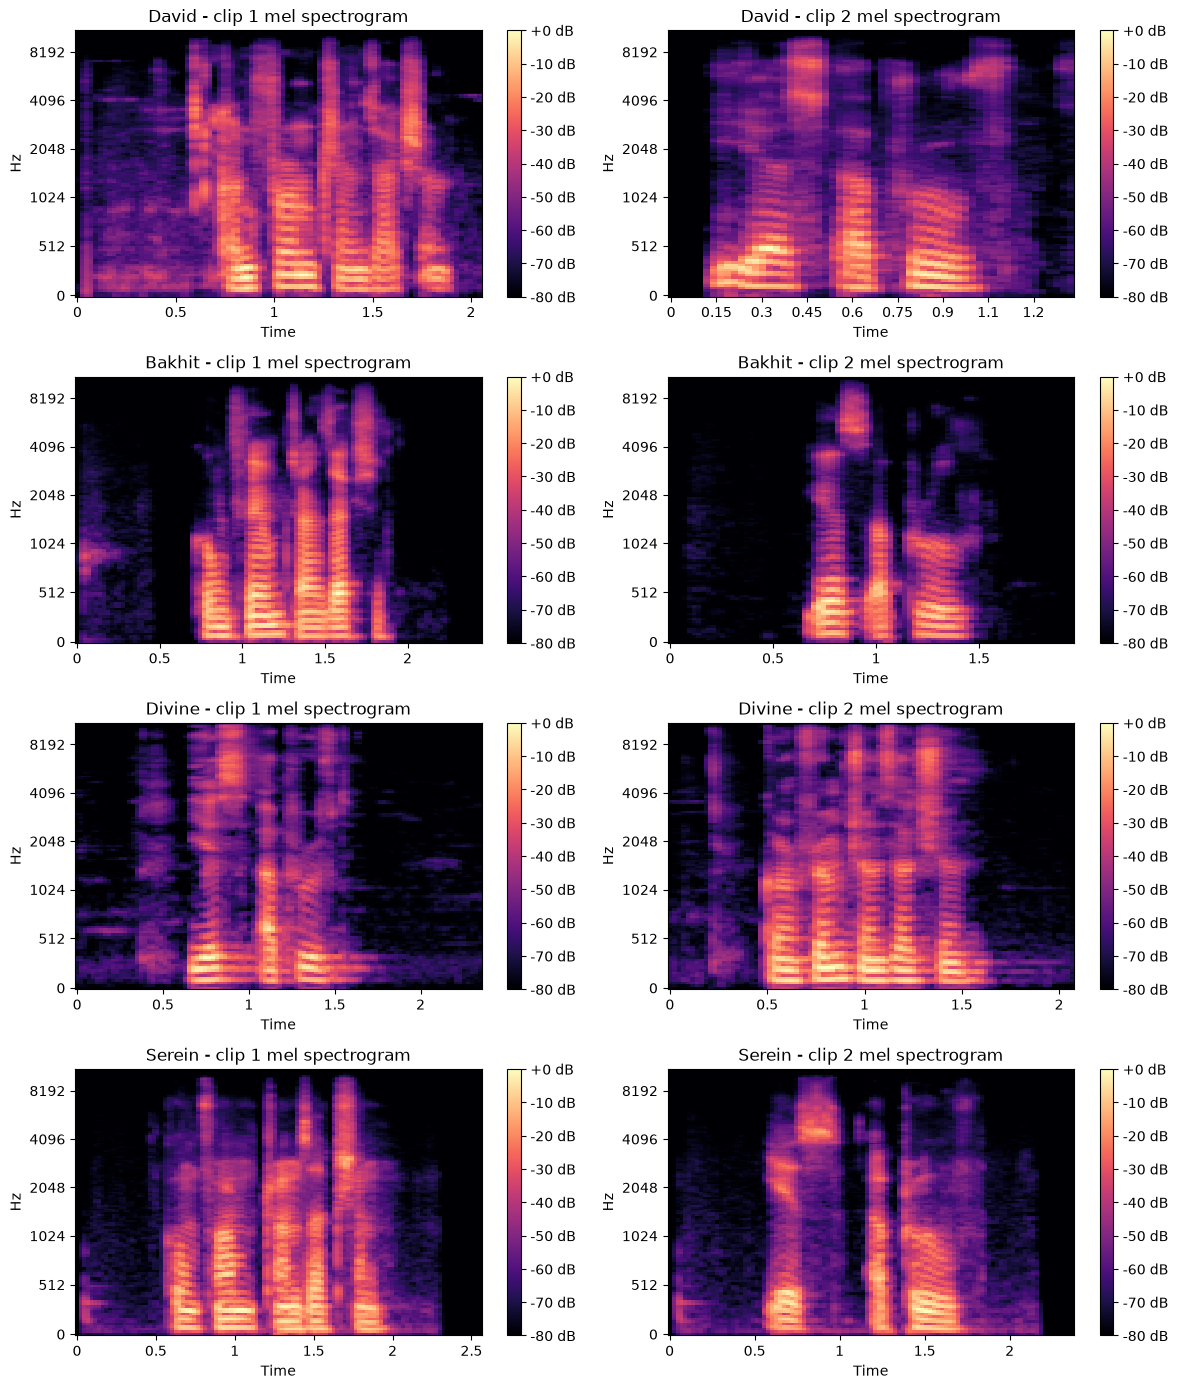

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
for row, name in enumerate(TEAM_MEMBERS):
    for col, path in enumerate(member_files[name]):
        y, sr = audio_data[path]
        mel = librosa.feature.melspectrogram(y=y, sr=sr)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        ax = axes[row, col]
        img = librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", ax=ax)
        ax.set_title(f"{name} - clip {col + 1} mel spectrogram")
        fig.colorbar(img, ax=ax, format="%+2.0f dB")
fig.tight_layout()
fig.savefig("../plots/audio_spectrograms.png", dpi=120)
plt.show()

All four members concentrate most of their energy below about 2048 Hz, which is normal for speech formants, but they differ in how much power reaches higher up the mel scale. Bakhit's two clips look the most self-consistent of the four: both show three bright bursts in almost the same relative timing and frequency spread, while David's two clips differ more from each other in burst count and shape. Divine's spectrograms carry visibly less bright, less energy-dense content overall, consistent with the low RMS energy already seen in the waveforms, which could make Divine's voiceprint harder to pin down from a noisier recording.

## 2. Audio Augmentation

Three augmentations are applied to each clip: pitch shift, time stretch, and Gaussian noise.

Pitch shift by 2 semitones simulates the natural variation in a person's voice between recordings, since nobody says the same phrase at exactly the same pitch every time. Time stretch by a factor of 1.2 handles differences in speaking speed, since a person talks faster or slower depending on mood or context, and the model still needs to recognize the voice regardless of pace. Gaussian noise at roughly 20dB SNR builds robustness to recording conditions, since a real deployment will not always have a clean microphone or a quiet room.

With only 2 real clips per member, these three augmentations triple the team data to 32 samples, which gives the Random Forest enough examples per class to learn a usable decision boundary.

In [6]:
def add_gaussian_noise(y, snr_db=20):
    signal_power = np.mean(y ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), size=y.shape)
    return y + noise

augmented_data = {}
for name in TEAM_MEMBERS:
    for path in member_files[name]:
        y, sr = audio_data[path]
        base = os.path.splitext(os.path.basename(path))[0]

        y_pitch = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=2)
        y_stretch = librosa.effects.time_stretch(y=y, rate=1.2)
        y_noise = add_gaussian_noise(y, snr_db=20)

        augmented_data[f"{base}_pitch"] = (y_pitch, sr, name)
        augmented_data[f"{base}_stretch"] = (y_stretch, sr, name)
        augmented_data[f"{base}_noise"] = (y_noise, sr, name)

n_original = sum(len(files) for files in member_files.values())
n_augmented = len(augmented_data)
print(f"original team clips: {n_original}")
print(f"augmented team clips: {n_augmented}")
print(f"total team samples: {n_original + n_augmented}")

original team clips: 8
augmented team clips: 24
total team samples: 32


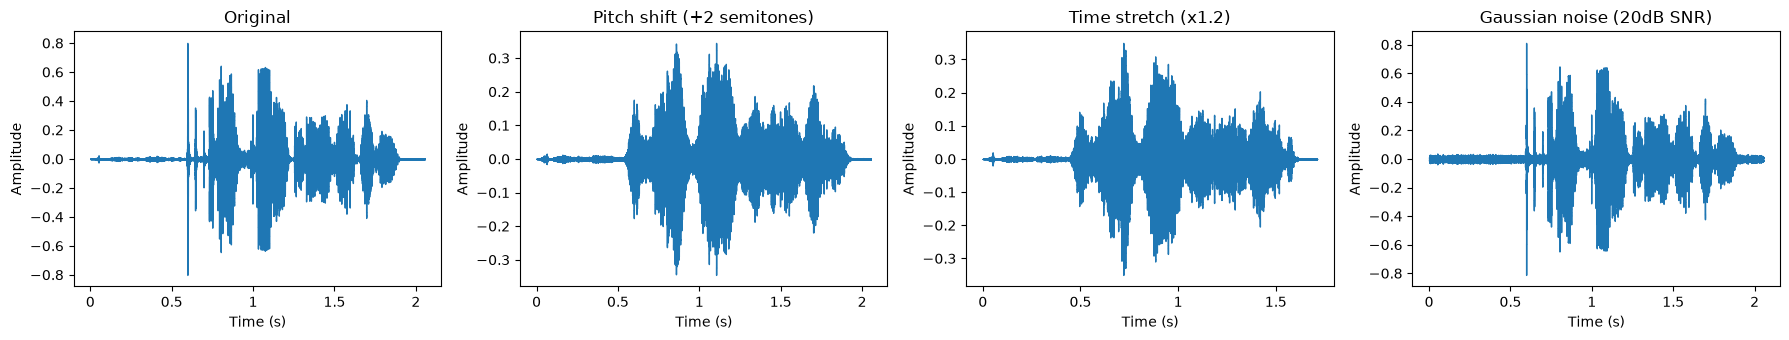

In [7]:
demo_member = "David"
demo_path = member_files[demo_member][0]
demo_base = os.path.splitext(os.path.basename(demo_path))[0]
y_orig, sr_orig = audio_data[demo_path]

fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))

librosa.display.waveshow(y_orig, sr=sr_orig, ax=axes[0])
axes[0].set_title("Original")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

y_pitch, sr_pitch, _ = augmented_data[f"{demo_base}_pitch"]
librosa.display.waveshow(y_pitch, sr=sr_pitch, ax=axes[1])
axes[1].set_title("Pitch shift (+2 semitones)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")

y_stretch, sr_stretch, _ = augmented_data[f"{demo_base}_stretch"]
librosa.display.waveshow(y_stretch, sr=sr_stretch, ax=axes[2])
axes[2].set_title("Time stretch (x1.2)")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Amplitude")

y_noise, sr_noise, _ = augmented_data[f"{demo_base}_noise"]
librosa.display.waveshow(y_noise, sr=sr_noise, ax=axes[3])
axes[3].set_title("Gaussian noise (20dB SNR)")
axes[3].set_xlabel("Time (s)")
axes[3].set_ylabel("Amplitude")

fig.tight_layout()
fig.savefig("../plots/audio_augmentation_comparison.png", dpi=120)
plt.show()

The time-stretched clip actually runs shorter than the original, ending around 1.7s instead of 2.05s: librosa's `rate` parameter speeds the signal up when it is greater than 1, so 1.2 means 20 percent faster, not slower. The pitch-shifted waveform keeps the same envelope and burst timing as the original, but the one large 0.8-amplitude spike from the original is smoothed down to about 0.3, since the pitch-shift algorithm resamples the signal and can flatten sharp transients. The noise version keeps the original's exact duration and envelope but adds visible jitter across the whole waveform, most obviously in the silent sections where the signal should sit flat at zero.

## 3. Feature Extraction

Three feature types are extracted per clip: 13 MFCCs, spectral roll-off, and RMS energy, each averaged across time.

MFCCs encode the shape of the vocal tract, which is the core signal for telling voices apart since every speaker's vocal tract resonates differently. Spectral roll-off captures the brightness of the voice, marking the frequency below which most of the energy sits, and voices differ in how much high-frequency content they carry. RMS energy captures the loudness profile of the clip, adding a simple signal on top of the timbre features.

Averaging each feature across time turns a variable-length clip into one fixed-length row, so every sample lines up in the same 15-column feature space regardless of clip length.

In [8]:
def extract_features(y, sr):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_means = mfccs.mean(axis=1)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()
    rms = librosa.feature.rms(y=y).mean()
    return mfcc_means, rolloff, rms

rows = []

for name in TEAM_MEMBERS:
    for path in member_files[name]:
        y, sr = audio_data[path]
        mfcc_means, rolloff, rms = extract_features(y, sr)
        row = {"member": name, "file": os.path.basename(path)}
        for i, val in enumerate(mfcc_means, start=1):
            row[f"mfcc_{i}"] = val
        row["spectral_rolloff"] = rolloff
        row["rms_energy"] = rms
        rows.append(row)

for aug_name, (y, sr, name) in augmented_data.items():
    mfcc_means, rolloff, rms = extract_features(y, sr)
    row = {"member": name, "file": f"{aug_name}.wav"}
    for i, val in enumerate(mfcc_means, start=1):
        row[f"mfcc_{i}"] = val
    row["spectral_rolloff"] = rolloff
    row["rms_energy"] = rms
    rows.append(row)

mfcc_cols = [f"mfcc_{i}" for i in range(1, 14)]
feature_cols = mfcc_cols + ["spectral_rolloff", "rms_energy"]
features_df = pd.DataFrame(rows, columns=["member", "file"] + feature_cols)
print(f"total samples: {len(features_df)}")
print(f"feature columns: {len(feature_cols)}")

total samples: 32
feature columns: 15


In [9]:
features_df.to_csv("../audio_features.csv", index=False)
print("saved ../audio_features.csv")
display(features_df.head(10))
print(features_df.shape)
display(features_df.describe())

saved ../audio_features.csv


,member,file,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_rolloff,rms_energy
0,David,David1.wav,-296.066772,107.935616,-18.233900,29.944798,-7.567034,8.293346,1.433071,8.824928,-19.372978,-2.832477,-5.382406,-4.399577,-10.247614,3557.938411,0.062441
1,David,David2.wav,-400.361511,90.146049,30.496372,27.345503,-21.370131,14.469974,-19.368181,8.996945,-17.348438,-12.995994,-6.797310,-6.835132,-3.933832,4150.339271,0.043480
2,Bakhit,Bakhit1.wav,-456.598846,81.114876,6.274734,23.149681,-10.856786,3.557880,-0.420582,-1.040278,-7.897811,4.677001,-6.047875,-6.149558,-0.736944,4076.275980,0.033868
3,Bakhit,Bakhit2.wav,-497.066833,66.674080,22.451197,10.945604,-7.277313,6.434544,-0.572757,-1.307763,-8.173674,-7.201695,-9.694810,-5.687666,2.755568,4255.720933,0.028083
4,Divine,Divine1.wav,-551.914734,50.207634,25.480463,22.931225,5.133670,10.028647,0.216246,-8.733157,-16.109913,-3.728852,-6.386210,-10.313129,-6.228040,5612.566062,0.008900
5,Divine,Divine2.wav,-517.407959,75.320625,30.439798,19.881481,10.687596,18.516323,-6.902915,-4.765562,-18.387848,-2.387310,-6.592415,-4.768227,-6.961296,5103.847656,0.012714
6,Serein,Serein1.wav,-412.964355,105.370827,-2.621909,27.700235,4.257367,4.010896,-1.263754,13.988756,-5.679803,-7.576769,-3.409034,3.437331,-4.604621,3436.776816,0.041954
7,Serein,Serein2.wav,-468.361908,86.264915,8.665638,32.843498,2.877434,5.455092,-0.359862,10.607968,-2.767837,-6.899302,-3.980180,1.935248,-4.638015,3878.589815,0.025559
8,David,David1_pitch.wav,-303.748291,92.076492,-10.915746,27.611742,-9.588940,10.124478,2.651471,-3.128366,-20.936155,1.182413,-8.564614,-5.546075,-10.613547,4179.014056,0.043108
9,David,David1_stretch.wav,-308.172302,102.851898,-16.933434,36.264492,-12.843686,11.714572,0.493681,9.221064,-20.535528,-1.993217,-6.159066,-3.559816,-10.520213,3796.536502,0.041282


(32, 17)


,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_rolloff,rms_energy
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,-418.589035,70.758593,14.274648,20.471610,-2.765307,6.855102,-3.389836,0.930394,-11.875942,-4.556386,-6.178177,-3.694350,-4.565120,5214.499277,0.027467
std,111.514434,26.906617,15.073264,9.070018,9.284949,5.039932,6.353109,7.933257,6.795422,4.480246,3.044241,3.934171,4.441433,1572.295036,0.015363
min,-583.498779,19.298964,-18.233900,4.910078,-23.323400,-0.392523,-21.219238,-16.941034,-28.896866,-14.782237,-11.737169,-10.658184,-13.396650,3436.776816,0.006265
25%,-502.152115,48.243696,4.895503,12.530296,-9.480955,3.529544,-4.323029,-3.784670,-17.777933,-7.137381,-7.891605,-5.803139,-7.161687,4053.601522,0.015586
50%,-433.726669,76.015583,14.866441,19.802441,-0.655961,5.621755,-1.143518,-1.118984,-11.002838,-5.487300,-6.300620,-4.478887,-4.813838,4492.371507,0.026502
75%,-307.066299,90.628660,25.673065,27.633865,3.446837,9.548351,0.256976,8.361722,-6.786157,-2.096435,-3.962199,-0.961847,-2.018945,6116.375234,0.037901
max,-187.626057,108.819344,40.400322,38.108711,12.748668,18.516323,3.795118,15.268693,-0.261975,5.725102,-0.924261,3.841690,3.419072,8402.488080,0.064702


Each member contributes 8 samples: 2 original clips plus 3 augmented versions of each, giving 32 rows total split evenly across 4 classes. The MFCC and roll-off ranges look like normal speech values: mfcc_1 runs from -583 to -188, spectral_rolloff from 3437 Hz to 8402 Hz, and rms_energy from 0.006 to 0.065. Divine stands out clearly in the per-member means, with rms_energy of 0.009 against 0.027 to 0.045 for the other three and spectral_rolloff of 6144 Hz against 4700 to 5200 Hz for the rest, so Divine's quiet, brighter-sounding voice is already visible in the numbers, not just the plots.

## 4. Voiceprint Verification Model

Random Forest is used because the dataset is small (32 samples, 15 features), so a deep model would overfit and add complexity with no benefit. It handles the mix of MFCC, roll-off, and energy features without needing feature scaling, since it splits on raw thresholds rather than distances. `class_weight="balanced"` guards against any imbalance the augmentation step might introduce, even though each member ends up with an equal 8 samples here.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = features_df[feature_cols]
y = features_df["member"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

voice_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
voice_model.fit(X_train, y_train)

print(f"train size: {len(X_train)}, test size: {len(X_test)}")
print("train class distribution:")
print(y_train.value_counts())
print("test class distribution:")
print(y_test.value_counts())

train size: 25, test size: 7
train class distribution:
member
David     7
Bakhit    6
Serein    6
Divine    6
Name: count, dtype: int64
test class distribution:
member
Bakhit    2
Serein    2
Divine    2
David     1
Name: count, dtype: int64


## 5. Evaluation

accuracy: 1.000
weighted F1: 1.000

              precision    recall  f1-score   support

      Bakhit       1.00      1.00      1.00         2
       David       1.00      1.00      1.00         1
      Divine       1.00      1.00      1.00         2
      Serein       1.00      1.00      1.00         2

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



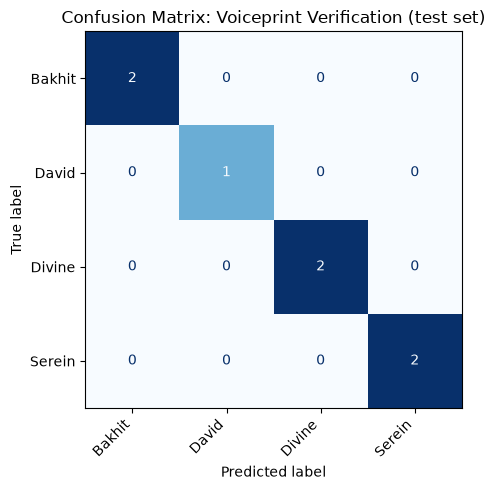

In [11]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = voice_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"accuracy: {acc:.3f}")
print(f"weighted F1: {f1:.3f}")
print()
print(classification_report(y_test, y_pred, zero_division=0))

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix: Voiceprint Verification (test set)")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig("../plots/audio_confusion_matrix.png", dpi=120)
plt.show()

The model gets every test sample right: accuracy 1.000, weighted F1 1.000, and every off-diagonal cell in the confusion matrix is 0 (Bakhit 2/2, David 1/1, Divine 2/2, Serein 2/2). That is not proof the voiceprint problem is easy: originals and their augmented pitch/stretch/noise versions were combined into one 32-row table before the split, so a clip's augmented siblings can land in training while the clip itself lands in test, meaning the model may be recognizing a near-copy of something it already saw rather than generalizing to new speech. With only 4 truly held-out, unaugmented clips per member, this result should be read as proof the feature pipeline and Random Forest work end to end, not as a real-world accuracy number.

## 6. Export verify_voice() for CLI

In [12]:
joblib.dump({"model": voice_model, "features": feature_cols}, "../models/voice_model.pkl")
print("saved ../models/voice_model.pkl")

def verify_voice(audio_path, threshold=0.5):
    y, sr = librosa.load(audio_path, sr=SR)
    mfcc_means, rolloff, rms = extract_features(y, sr)
    row = {f"mfcc_{i}": val for i, val in enumerate(mfcc_means, start=1)}
    row["spectral_rolloff"] = rolloff
    row["rms_energy"] = rms
    x_row = pd.DataFrame([row], columns=feature_cols)

    proba = voice_model.predict_proba(x_row)[0]
    classes = voice_model.classes_
    best_idx = np.argmax(proba)
    confidence = proba[best_idx]
    predicted = classes[best_idx]

    if confidence > threshold:
        return predicted, confidence
    return "unauthorized", confidence

# demo on one original test-set clip (verify_voice loads from disk, so pick a
# test row whose file is a real .wav on disk, not an in-memory augmented clip)
test_originals = [
    idx for idx in X_test.index
    if not any(tag in features_df.loc[idx, "file"] for tag in ["_pitch", "_stretch", "_noise"])
]

if test_originals:
    demo_idx = test_originals[0]
    demo_file = features_df.loc[demo_idx, "file"]
    demo_actual = features_df.loc[demo_idx, "member"]
    demo_path = f"{AUDIO_DIR}/{demo_file}"
    label, confidence = verify_voice(demo_path)
    print(f"test sample: {demo_file} (actual: {demo_actual}) -> predicted={label}, confidence={confidence:.3f}")
else:
    print("no original clip landed in the test split this run; demo skipped")

for path in stranger_files:
    label, confidence = verify_voice(path)
    print(f"{os.path.basename(path)}: predicted={label}, confidence={confidence:.3f}")

saved ../models/voice_model.pkl
test sample: Serein2.wav (actual: Serein) -> predicted=Serein, confidence=0.885
stranger1.wav: predicted=Serein, confidence=0.550
stranger2.wav: predicted=Serein, confidence=0.535


/var/folders/7h/f1hhjprx7n7f5vnswz78l0kh0000gn/T/ipykernel_6073/2459222596.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=SR)
/private/tmp/claude-501/-Users-macbook-Desktop-Project-Multimodal-Data-Preprocessing/abd8ede9-db1d-4b10-8729-40bd11871dd1/scratchpad/venv312/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/var/folders/7h/f1hhjprx7n7f5vnswz78l0kh0000gn/T/ipykernel_6073/2459222596.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=SR)
/private/tmp/claude-501/-Users-macbook-Desktop-Project-Multimodal-Data-Preprocessing/abd8ede9-db1d-4b10-8729-40bd11871dd1/scratchpad/venv312/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audi

On this run, the test-set demo correctly identifies Serein2.wav as Serein with confidence 0.885, comfortably above the 0.5 gate. Both stranger clips, though, are not rejected: stranger1.wav lands as Serein at confidence 0.550 and stranger2.wav also as Serein at confidence 0.535, just over the threshold instead of under it. With only 4 known classes, a Random Forest's predict_proba can push an unfamiliar voice's probability mass onto whichever class it resembles most by chance, so a flat 0.5 cutoff is not a strict guarantee against false acceptance; a higher threshold, or a genuine one-class/outlier check trained only on team data, would close this gap.

## 7. Summary

- **Data:** loaded 8 real clips across 4 team members (2 each), plus 2 stranger clips held out for the unauthorized-access test.
- **Augmentation:** pitch shift, time stretch, and Gaussian noise applied to each original clip, giving 24 augmented samples and 32 team samples total.
- **Features:** 13 MFCCs, spectral roll-off, and RMS energy extracted per sample, averaged across time, for 15 feature columns saved to `audio_features.csv`.
- **Model:** RandomForestClassifier(n_estimators=200, class_weight="balanced") trained on an 80/20 stratified split.
- **Evaluation:** accuracy and weighted F1 both hit 1.000 on the 7-sample test set, with a perfectly diagonal confusion matrix. This is likely inflated by augmented siblings of a test clip leaking into the training set, not a real-world guarantee.
- **Export:** `verify_voice()` saved alongside the pickled model in `models/voice_model.pkl`. It correctly identified a held-out Serein clip at 0.885 confidence, but it did not reject either stranger clip: both were misclassified as Serein, at 0.550 and 0.535 confidence, just above the 0.5 gate. The unauthorized-voice check needs a higher threshold or an actual outlier detector before it can be trusted.